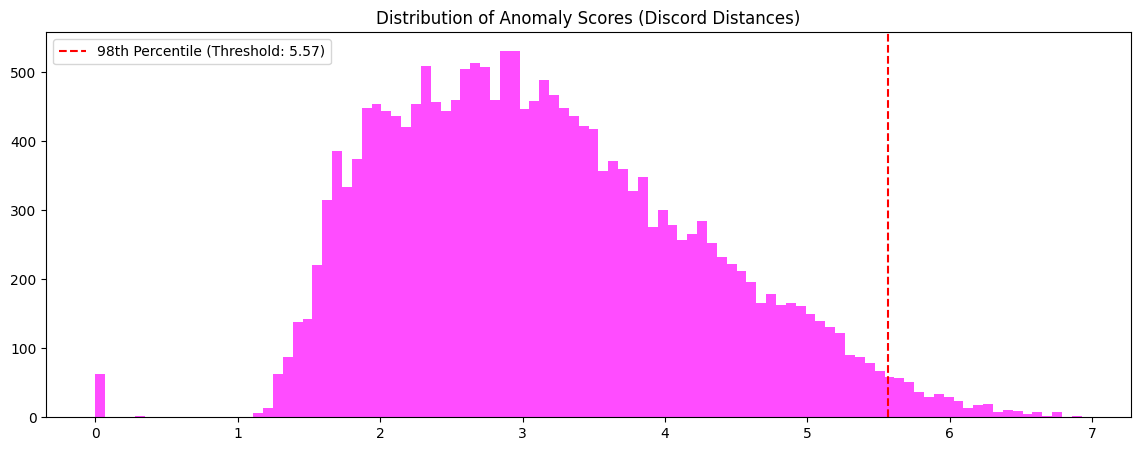

Ваш порог для 'Черного лебедя' (Kill Switch): 5.57


In [5]:
import pandas as pd
import numpy as np
import stumpy
import matplotlib.pyplot as plt

# 1. Загрузка данных
df = pd.read_parquet('../data/processed/gbpusd_15m.parquet').tail(20000)

# Очистка цены
df = df.dropna(subset=['close'])
T = df['close'].astype(float).values

m = 48 # Окно в 48 свечей (12 часов)

# 2. Вычисление Matrix Profile
mp = stumpy.stump(T, m)

# === БРОНЕБОЙНАЯ ОЧИСТКА ДИСТАНЦИЙ ===
# Берем первую колонку (дистанции) и принудительно переводим во float
distances = mp[:, 0].astype(float)

# Оставляем ТОЛЬКО конечные числа (удаляем бесконечности (inf) и пустоты (nan), которые оставляет STUMPY)
clean_distances = distances[np.isfinite(distances)]
# ====================================

# 3. Анализ аномалий
# Теперь считаем перцентиль только по чистым данным
threshold = np.percentile(clean_distances, 98) 

plt.figure(figsize=(14, 5))
plt.hist(clean_distances, bins=100, color='magenta', alpha=0.7)
plt.axvline(threshold, color='red', linestyle='--', label=f'98th Percentile (Threshold: {threshold:.2f})')
plt.title('Distribution of Anomaly Scores (Discord Distances)')
plt.legend()
plt.show()

print(f"Ваш порог для 'Черного лебедя' (Kill Switch): {threshold:.2f}")